In [1]:
!pip install qiskit qiskit_aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


[True Markovian] Step 1 | S(R) ≈ 1.0000
[True Markovian] Step 2 | S(R) ≈ 2.0000
[True Markovian] Step 3 | S(R) ≈ 3.0000
[True Markovian] Step 4 | S(R) ≈ 4.0000
[True Markovian] Step 5 | S(R) ≈ 5.0000
[True Markovian] Step 6 | S(R) ≈ 6.0000
[True Markovian] Step 7 | S(R) ≈ 7.0000
[True Markovian] Step 8 | S(R) ≈ 8.0000
[Non-Markovian] Step 1 | S(R) = 0.9959
[Non-Markovian] Step 2 | S(R) = 1.9942
[Non-Markovian] Step 3 | S(R) = 2.9878
[Non-Markovian] Step 4 | S(R) = 3.9538
[Non-Markovian] Step 5 | S(R) = 4.8160
[Non-Markovian] Step 6 | S(R) = 5.2787
[Non-Markovian] Step 7 | S(R) = 4.8278
[Non-Markovian] Step 8 | S(R) = 3.9571


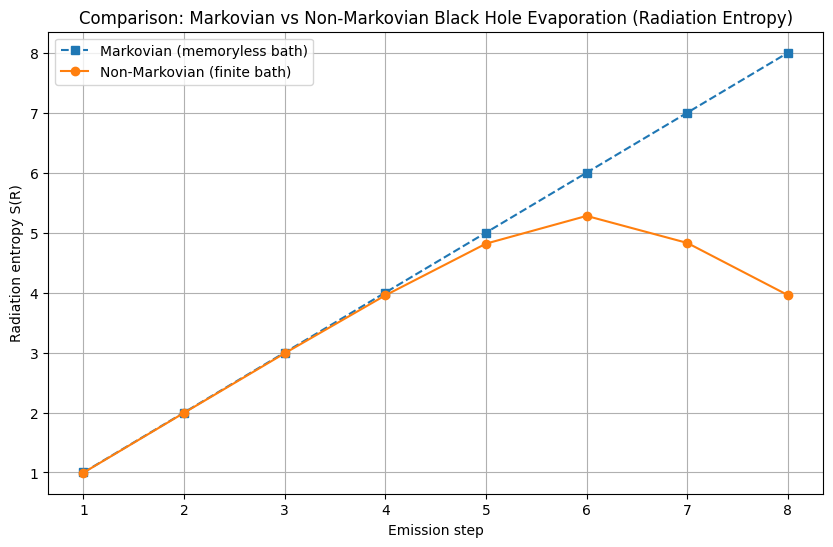

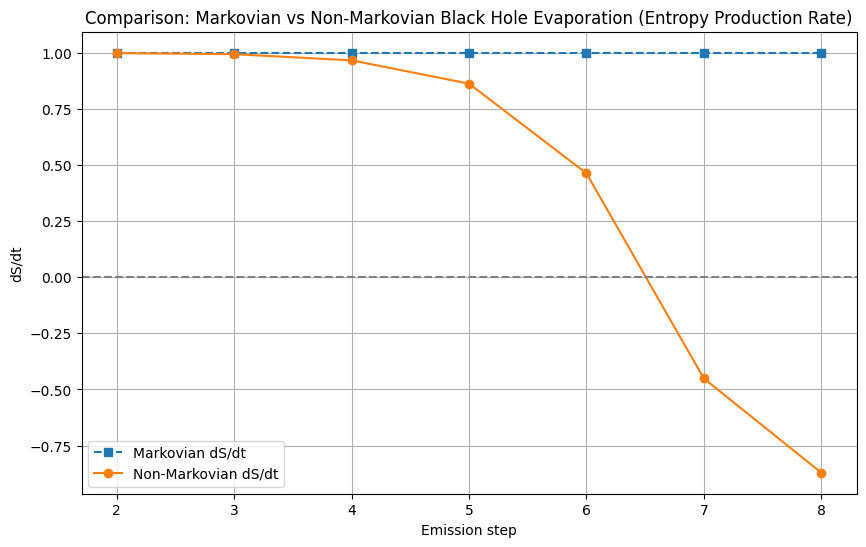

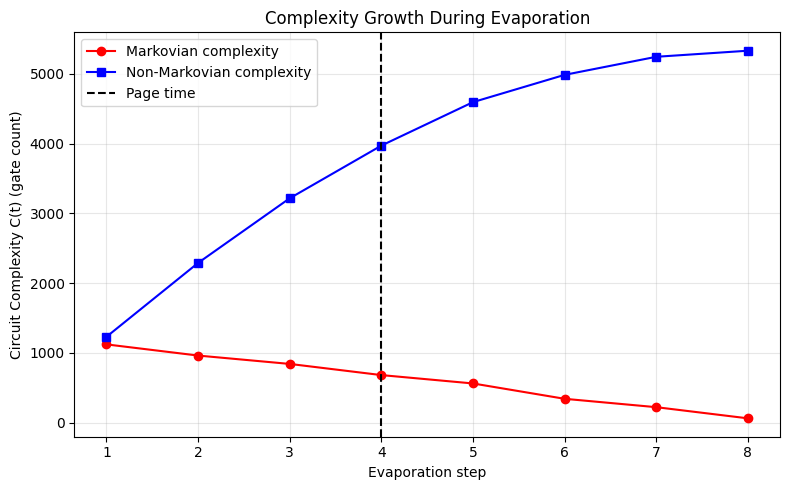

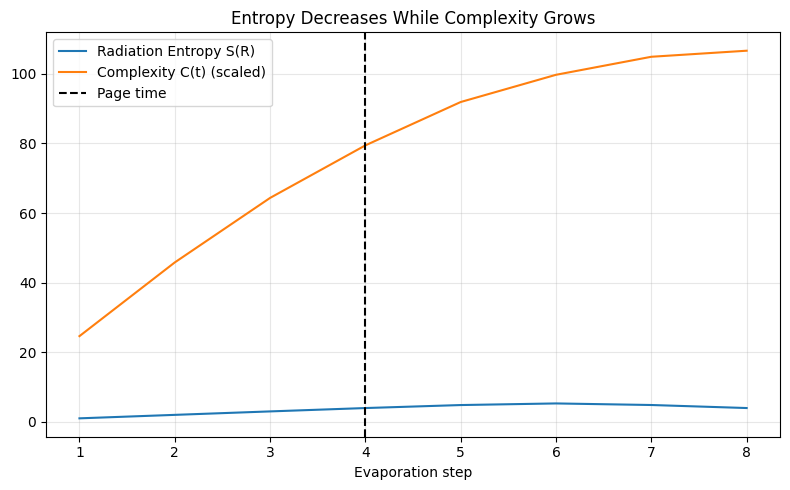

In [4]:
%run MvNM_base.ipynb

SYSTEMATIC OTOC EXPERIMENT
BH sizes: [8]
ENV sizes: [2, 4, 6]
V position: 0
W positions: all
Iterations per config: 3

Testing: BH=8, ENV=2, W=8 (ENV[0]), Iteration 1/3
  t_leak: 4
  t_bounce: -1
  min_OTOC: -0.0303
  zero_crossings: 5

Testing: BH=8, ENV=2, W=8 (ENV[0]), Iteration 2/3
  t_leak: 3
  t_bounce: 9
  min_OTOC: -0.0684
  zero_crossings: 5

Testing: BH=8, ENV=2, W=8 (ENV[0]), Iteration 3/3
  t_leak: 1
  t_bounce: 9
  min_OTOC: -0.0840
  zero_crossings: 3

Testing: BH=8, ENV=2, W=9 (ENV[1]), Iteration 1/3
  t_leak: 1
  t_bounce: 7
  min_OTOC: -0.0576
  zero_crossings: 4

Testing: BH=8, ENV=2, W=9 (ENV[1]), Iteration 2/3
  t_leak: 4
  t_bounce: -1
  min_OTOC: -0.0537
  zero_crossings: 3

Testing: BH=8, ENV=2, W=9 (ENV[1]), Iteration 3/3
  t_leak: 2
  t_bounce: 5
  min_OTOC: -0.0801
  zero_crossings: 5

Testing: BH=8, ENV=4, W=8 (ENV[0]), Iteration 1/3
  t_leak: 2
  t_bounce: -1
  min_OTOC: -0.0254
  zero_crossings: 6

Testing: BH=8, ENV=4, W=8 (ENV[0]), Iteration 2/3
  t_leak:

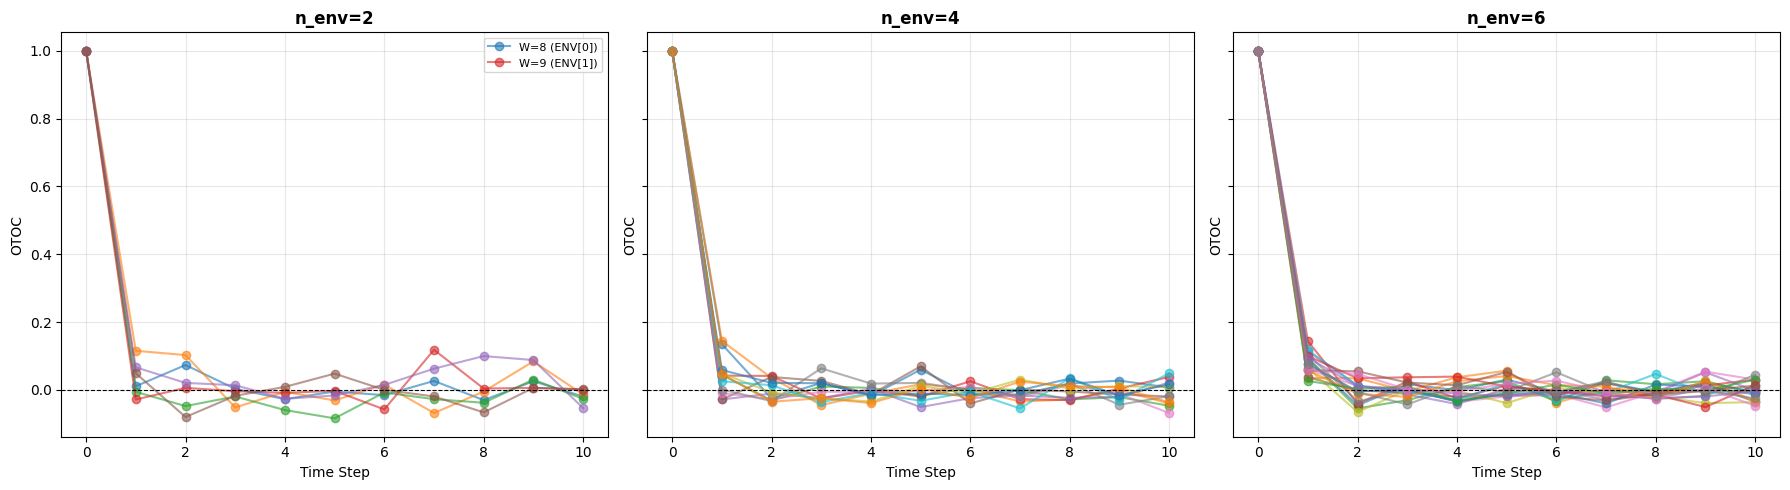

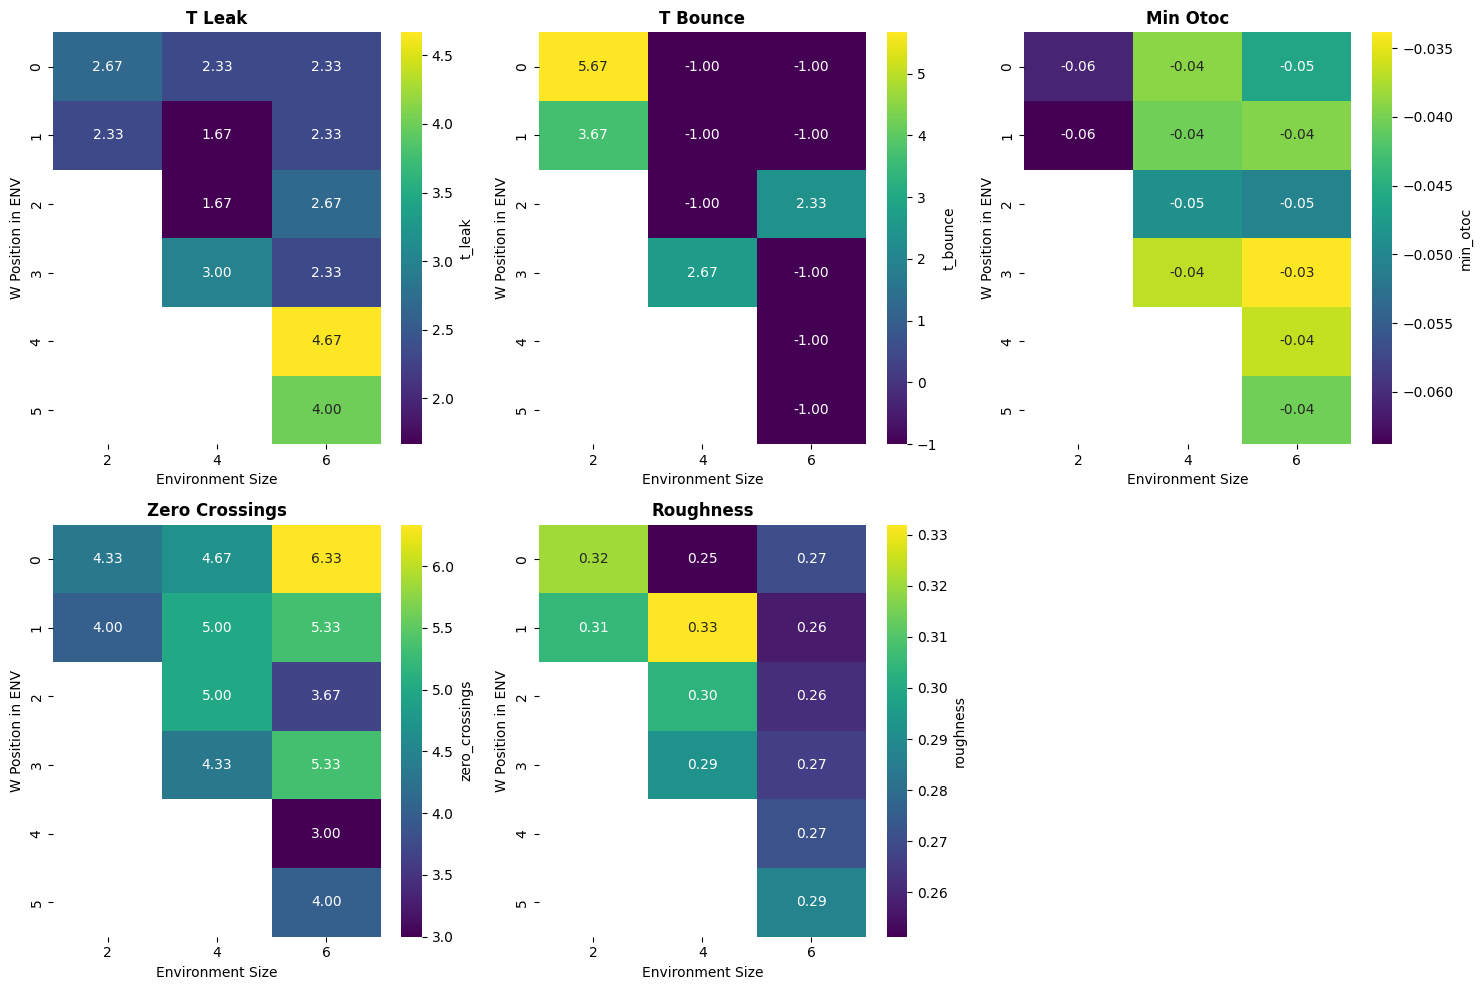

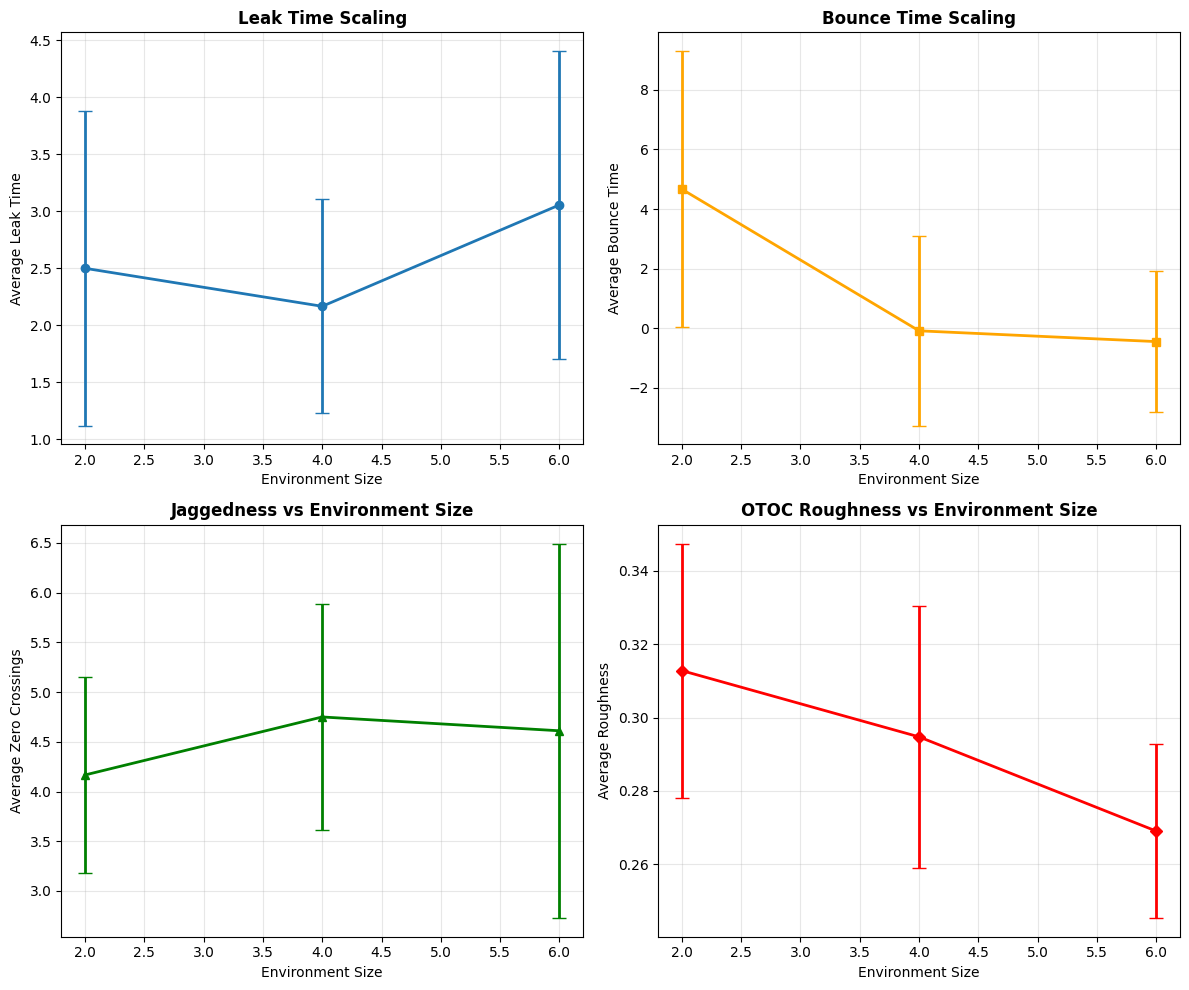

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import seaborn as sns
from datetime import datetime

# ============================================================================
# CONFIGURATION - Change these for different experiments
# ============================================================================

class ExperimentConfig:
    """Central configuration to avoid manual errors"""

    # System sizes to test
    BH_SIZES = [8]  # Can add more: [6, 8, 10]
    ENV_SIZES = [2, 4, 6]  # Different environment sizes

    # Operator positions
    V_POSITION = 0  # Always at BH qubit 0 (deep inside)
    W_POSITIONS = 'all'  # 'all' or specific list [0, 1, 2]

    # Simulation parameters
    MAX_STEPS = 10
    SHOTS = 2048
    NUM_ITERATIONS = 3  # Repeat each config for statistics

    # What to test
    TEST_MODE = 'env_size_scan'  # Options: 'env_size_scan', 'w_position_scan', 'full_matrix'


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def create_otoc_circuit(n_bh, n_env, v_qubit, w_qubit, U_step_gate,
                        U_step_dag_gate, step):
    """
    Create OTOC measurement circuit

    Args:
        n_bh: Black hole size
        n_env: Environment size
        v_qubit: Position of V operator
        w_qubit: Position of W operator
        U_step_gate: Forward evolution gate
        U_step_dag_gate: Backward evolution gate
        step: Number of time steps
    """
    n_total = n_bh + n_env
    ancilla_idx = n_total

    qc = QuantumCircuit(n_total + 1, 1)
    qc.h(ancilla_idx)

    sys_qubits = list(range(n_total))

    # V operator
    qc.cz(ancilla_idx, v_qubit)

    # Forward evolution
    for _ in range(step):
        qc.append(U_step_gate, sys_qubits)

    # W operator
    qc.x(w_qubit)

    # Backward evolution
    for _ in range(step):
        qc.append(U_step_dag_gate, sys_qubits)

    # V†
    qc.cz(ancilla_idx, v_qubit)

    # Forward evolution
    for _ in range(step):
        qc.append(U_step_gate, sys_qubits)

    # W†
    qc.x(w_qubit)

    # Backward evolution
    for _ in range(step):
        qc.append(U_step_dag_gate, sys_qubits)

    # Measurement
    qc.h(ancilla_idx)
    qc.measure(ancilla_idx, 0)

    return qc


def measure_otoc(qc, simulator, shots=2048):
    """Run circuit and extract OTOC value"""
    qc_transpiled = transpile(qc, simulator)
    result = simulator.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()

    p_0 = counts.get('0', 0) / shots
    otoc_real = 2 * p_0 - 1

    return otoc_real


def analyze_otoc_curve(otoc_values):
    """Extract key features from OTOC curve"""
    otoc_array = np.array(otoc_values)

    # Find when OTOC first goes negative
    negative_indices = np.where(otoc_array < 0)[0]
    t_leak = negative_indices[0] if len(negative_indices) > 0 else -1

    # Find minimum OTOC value
    min_otoc = np.min(otoc_array)
    t_min = np.argmin(otoc_array)

    # Find bounce (first significant upturn after minimum)
    t_bounce = -1
    for i in range(t_min + 1, len(otoc_array)):
        if otoc_array[i] > min_otoc + 0.1:
            t_bounce = i
            break

    # Count zero crossings (jaggedness)
    zero_crossings = np.sum(np.diff(np.sign(otoc_array)) != 0)

    # Compute roughness (variance of second derivative)
    if len(otoc_array) > 2:
        d2_otoc = np.diff(otoc_array, n=2)
        roughness = np.std(d2_otoc)
    else:
        roughness = 0

    return {
        't_leak': t_leak,
        't_min': t_min,
        'min_otoc': min_otoc,
        't_bounce': t_bounce,
        'zero_crossings': zero_crossings,
        'roughness': roughness
    }


# ============================================================================
# MAIN EXPERIMENT RUNNER
# ============================================================================

def run_single_configuration(n_bh, n_env, v_qubit, w_qubit,
                            scramble_fn, evolve_fn, interact_fn,
                            max_steps=10, shots=2048, iteration=0):
    """
    Run OTOC measurement for a single configuration

    Returns:
        dict with otoc_values and metadata
    """
    n_total = n_bh + n_env

    # Create evolution gate (frozen dynamics)
    step_qc = QuantumCircuit(n_total, name=f"U_step_BH{n_bh}_ENV{n_env}")
    bh_qubits = list(range(n_bh))
    env_qubits = list(range(n_bh, n_total))

    scramble_fn(step_qc, bh_qubits)
    evolve_fn(step_qc, env_qubits)
    interact_fn(step_qc, bh_qubits, env_qubits)

    U_step_gate = step_qc.to_gate()
    U_step_dag_gate = U_step_gate.inverse()

    # Measure OTOC at each time step
    simulator = AerSimulator()
    otoc_values = []

    for step in range(max_steps + 1):
        qc = create_otoc_circuit(n_bh, n_env, v_qubit, w_qubit,
                                U_step_gate, U_step_dag_gate, step)

        otoc = measure_otoc(qc, simulator, shots)
        otoc_values.append(otoc)

    # Analyze results
    analysis = analyze_otoc_curve(otoc_values)

    return {
        'n_bh': n_bh,
        'n_env': n_env,
        'n_total': n_total,
        'env_bh_ratio': n_env / n_bh,
        'v_qubit': v_qubit,
        'w_qubit': w_qubit,
        'w_position_in_env': w_qubit - n_bh,
        'iteration': iteration,
        'otoc_values': otoc_values,
        **analysis
    }


def run_experiment_matrix(config, scramble_fn, evolve_fn, interact_fn):
    """
    Run full experiment matrix based on configuration

    Returns:
        pandas DataFrame with all results
    """
    results = []

    # Determine W positions to test
    for n_bh in config.BH_SIZES:
        for n_env in config.ENV_SIZES:

            # Determine which W positions to test
            if config.W_POSITIONS == 'all':
                w_positions = list(range(n_bh, n_bh + n_env))
            else:
                w_positions = [n_bh + w for w in config.W_POSITIONS if w < n_env]

            for w_qubit in w_positions:
                for iteration in range(config.NUM_ITERATIONS):

                    print(f"\n{'='*70}")
                    print(f"Testing: BH={n_bh}, ENV={n_env}, W={w_qubit} (ENV[{w_qubit-n_bh}]), Iteration {iteration+1}/{config.NUM_ITERATIONS}")
                    print(f"{'='*70}")

                    result = run_single_configuration(
                        n_bh=n_bh,
                        n_env=n_env,
                        v_qubit=config.V_POSITION,
                        w_qubit=w_qubit,
                        scramble_fn=scramble_fn,
                        evolve_fn=evolve_fn,
                        interact_fn=interact_fn,
                        max_steps=config.MAX_STEPS,
                        shots=config.SHOTS,
                        iteration=iteration
                    )

                    results.append(result)

                    # Print quick summary
                    print(f"  t_leak: {result['t_leak']}")
                    print(f"  t_bounce: {result['t_bounce']}")
                    print(f"  min_OTOC: {result['min_otoc']:.4f}")
                    print(f"  zero_crossings: {result['zero_crossings']}")

    return pd.DataFrame(results)


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_otoc_curves(df, group_by='n_env'):
    """Plot OTOC curves grouped by specified parameter"""

    fig, axes = plt.subplots(1, len(df[group_by].unique()),
                            figsize=(6*len(df[group_by].unique()), 5),
                            sharex=True, sharey=True)

    if len(df[group_by].unique()) == 1:
        axes = [axes]

    for idx, group_val in enumerate(sorted(df[group_by].unique())):
        ax = axes[idx]
        subset = df[df[group_by] == group_val]

        for _, row in subset.iterrows():
            label = f"W={row['w_qubit']} (ENV[{row['w_position_in_env']}])"
            if row['iteration'] > 0:
                label = None  # Only label first iteration

            ax.plot(row['otoc_values'], marker='o', alpha=0.6,
                   label=label, linewidth=1.5)

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(f"{group_by}={group_val}", fontweight='bold')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('OTOC')
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


def plot_summary_heatmaps(df):
    """Create heatmaps of key metrics"""

    # Average over iterations
    df_avg = df.groupby(['n_env', 'w_position_in_env']).agg({
        't_leak': 'mean',
        't_bounce': 'mean',
        'min_otoc': 'mean',
        'zero_crossings': 'mean',
        'roughness': 'mean'
    }).reset_index()

    metrics = ['t_leak', 't_bounce', 'min_otoc', 'zero_crossings', 'roughness']

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        pivot = df_avg.pivot(index='w_position_in_env',
                            columns='n_env',
                            values=metric)

        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis',
                   ax=ax, cbar_kws={'label': metric})

        ax.set_title(f'{metric.replace("_", " ").title()}', fontweight='bold')
        ax.set_xlabel('Environment Size')
        ax.set_ylabel('W Position in ENV')

    # Remove extra subplot
    fig.delaxes(axes[-1])

    plt.tight_layout()
    return fig


def plot_scaling_analysis(df):
    """Analyze scaling behavior"""

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Average over iterations and W positions
    df_avg = df.groupby('n_env').agg({
        't_leak': ['mean', 'std'],
        't_bounce': ['mean', 'std'],
        'zero_crossings': ['mean', 'std'],
        'roughness': ['mean', 'std']
    }).reset_index()

    # Plot 1: Leak time vs ENV size
    ax = axes[0, 0]
    ax.errorbar(df_avg['n_env'], df_avg[('t_leak', 'mean')],
               yerr=df_avg[('t_leak', 'std')], marker='o', capsize=5, linewidth=2)
    ax.set_xlabel('Environment Size')
    ax.set_ylabel('Average Leak Time')
    ax.set_title('Leak Time Scaling', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Plot 2: Bounce time vs ENV size
    ax = axes[0, 1]
    ax.errorbar(df_avg['n_env'], df_avg[('t_bounce', 'mean')],
               yerr=df_avg[('t_bounce', 'std')], marker='s', capsize=5, linewidth=2, color='orange')
    ax.set_xlabel('Environment Size')
    ax.set_ylabel('Average Bounce Time')
    ax.set_title('Bounce Time Scaling', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Plot 3: Jaggedness vs ENV size
    ax = axes[1, 0]
    ax.errorbar(df_avg['n_env'], df_avg[('zero_crossings', 'mean')],
               yerr=df_avg[('zero_crossings', 'std')], marker='^', capsize=5, linewidth=2, color='green')
    ax.set_xlabel('Environment Size')
    ax.set_ylabel('Average Zero Crossings')
    ax.set_title('Jaggedness vs Environment Size', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Plot 4: Roughness vs ENV size
    ax = axes[1, 1]
    ax.errorbar(df_avg['n_env'], df_avg[('roughness', 'mean')],
               yerr=df_avg[('roughness', 'std')], marker='D', capsize=5, linewidth=2, color='red')
    ax.set_xlabel('Environment Size')
    ax.set_ylabel('Average Roughness')
    ax.set_title('OTOC Roughness vs Environment Size', fontweight='bold')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":

    # Import your dynamics functions
    # from your_module import scramble_black_hole, evolve_environment, bh_environment_interaction

    # Configure experiment
    config = ExperimentConfig()
    config.BH_SIZES = [8]
    config.ENV_SIZES = [2, 4, 6]
    config.W_POSITIONS = 'all'  # Test all W positions
    config.MAX_STEPS = 10
    config.NUM_ITERATIONS = 3

    print("="*70)
    print("SYSTEMATIC OTOC EXPERIMENT")
    print("="*70)
    print(f"BH sizes: {config.BH_SIZES}")
    print(f"ENV sizes: {config.ENV_SIZES}")
    print(f"V position: {config.V_POSITION}")
    print(f"W positions: {config.W_POSITIONS}")
    print(f"Iterations per config: {config.NUM_ITERATIONS}")
    print("="*70)

    # Run experiments
    results_df = run_experiment_matrix(
        config,
        scramble_fn=scramble_black_hole,  # Your function
        evolve_fn=evolve_environment,      # Your function
        interact_fn=bh_environment_interaction  # Your function
    )

    # Save raw data
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_df.to_csv(f'otoc_results_{timestamp}.csv', index=False)
    print(f"\n✓ Results saved to otoc_results_{timestamp}.csv")

    # Generate plots
    print("\nGenerating visualizations...")

    fig1 = plot_otoc_curves(results_df, group_by='n_env')
    fig1.savefig(f'otoc_curves_{timestamp}.png', dpi=300, bbox_inches='tight')

    fig2 = plot_summary_heatmaps(results_df)
    fig2.savefig(f'otoc_heatmaps_{timestamp}.png', dpi=300, bbox_inches='tight')

    fig3 = plot_scaling_analysis(results_df)
    fig3.savefig(f'otoc_scaling_{timestamp}.png', dpi=300, bbox_inches='tight')

    print("✓ Figures saved!")

    # Print summary table
    print("\n" + "="*70)
    print("SUMMARY TABLE (averaged over iterations)")
    print("="*70)

    summary = results_df.groupby(['n_bh', 'n_env', 'w_position_in_env']).agg({
        't_leak': 'mean',
        't_bounce': 'mean',
        'min_otoc': 'mean',
        'zero_crossings': 'mean'
    }).round(2)

    print(summary)

    plt.show()